In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 00 — Data Preprocessing

Loads the raw Homesite Insurance training CSV and produces a clean tabular dataset with a temporal key (`quote_date`), ready for the rolling-window experiment.

The feature engineering recipe replicates [TabReD's `preprocessing/homesite.py`](https://github.com/yandex-research/tabred/blob/main/preprocessing/homesite.py) so the rolling-window study downstream operates on a benchmark-faithful matrix. Two intentional deviations from TabReD:

- **Per-replica categorical encoding.** `OrdinalEncoder(min_frequency=1/100)` is fitted inside the training notebook on each bootstrap sample (analogous to the `StandardScaler` pattern used for numerics in the Shoppers reference), not once globally here. `X_cat.parquet` therefore stores raw string categoricals.
- **Missingness sentinel + indicators.** TabReD propagates `NaN` through to the saved Float32 columns. To preserve the Shoppers downstream contract (`X.parquet` must be NaN-free for `.values.astype(np.float32)`), we add `__missing` indicators where any NaN appears (including the −1→NaN replacement done for A/B columns) and refill the underlying value with `-1`.

**Input:** `data/raw/train.csv`  
**Output:**
- `data/processed/X.parquet` — numeric + binary feature matrix (Shoppers-compatible)  
- `data/processed/X_num.parquet` — numeric feature matrix (float32)  
- `data/processed/X_bin.parquet` — binary indicator matrix (int8)  
- `data/processed/X_cat.parquet` — raw string categoricals (object)  
- `data/processed/Y.npy` — binary labels (1 = converted)  
- `data/processed/meta.parquet` — `[QuoteNumber, quote_date]`  
- `data/processed/feature_names.json` — `{'all', 'num', 'bin', 'cat'}` registry  

**Convention:** `'all' == 'num' + 'bin'` matches `X.parquet` columns. `'cat'` is a separate group, loaded only by notebooks that handle categoricals.

In [9]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────
# WORKSPACE : root folder for all notebook inputs/outputs
# RAW_DIR   : raw CSV input (write-once, never modified by this notebook)
# CACHE_DIR : intermediate parquet cache; skips redundant CSV parse on re-runs
# PROC_DIR  : final artefacts consumed by downstream notebooks (X, Y, meta, ...)
# FIG_DIR   : EDA figure output directory
WORKSPACE = Path('/content/drive/MyDrive/Thesis/Homesite_workspace')
RAW_DIR   = WORKSPACE / 'data' / 'raw'
CACHE_DIR = WORKSPACE / 'data' / 'cache'
PROC_DIR  = WORKSPACE / 'data' / 'processed'
FIG_DIR   = PROC_DIR / 'figures'

for d in [RAW_DIR, CACHE_DIR, PROC_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_CSV = RAW_DIR / 'train.csv'

# Reproducibility seed (only used by any randomized step further down, e.g. EDA sampling)
np.random.seed(0)

print('Paths OK')
print(f'  RAW_CSV  : {RAW_CSV}')
print(f'  CACHE_DIR: {CACHE_DIR}')
print(f'  PROC_DIR : {PROC_DIR}')
print(f'  FIG_DIR  : {FIG_DIR}')

Paths OK
  RAW_CSV  : /content/drive/MyDrive/Thesis/Homesite_workspace/data/raw/train.csv
  CACHE_DIR: /content/drive/MyDrive/Thesis/Homesite_workspace/data/cache
  PROC_DIR : /content/drive/MyDrive/Thesis/Homesite_workspace/data/processed
  FIG_DIR  : /content/drive/MyDrive/Thesis/Homesite_workspace/data/processed/figures


## 1. Load raw Homesite training data

The Kaggle Homesite Insurance dataset has one row per quote (≈260 k quotes spanning Jan 2013 – May 2015), 299 columns, and a binary target `QuoteConversion_Flag`. Most predictors are anonymised numeric or categorical fields grouped into families:

| Prefix | Meaning |
|---|---|
| `Field*` | Generic anonymised features |
| `CoverageField*` | Coverage-level information |
| `SalesField*` | Sales channel / process information |
| `PersonalField*` | Personal characteristics of the quote requester |
| `PropertyField*` | Information about the property being insured |
| `GeographicField*` | Location features |

Many integer fields end in `A` or `B` — these are paired ordinal encodings where the value `-1` denotes "missing" (a TabReD-specified semantic that we restore in section 3).

The cell below loads from a parquet cache if one exists (the cleaned dataframe written at the end of section 2); otherwise it reads the raw CSV.

In [10]:
cache_path = CACHE_DIR / 'train_clean.parquet'

if cache_path.exists():
    print(f'Loading cached cleaned data from {cache_path}')
    df = pd.read_parquet(cache_path)
    loaded_from_cache = True
else:
    if not RAW_CSV.exists():
        raise FileNotFoundError(
            f'Raw data not found at {RAW_CSV}. '
            f'Place the Homesite Kaggle train.csv in {RAW_DIR} and re-run.'
        )
    print(f'Reading raw CSV: {RAW_CSV}')
    df = pd.read_csv(RAW_CSV)
    loaded_from_cache = False

print(f'Loaded shape: {df.shape}')
print(f'Dtype counts:\n{df.dtypes.value_counts()}')
df.head(3)

Reading raw CSV: /content/drive/MyDrive/Thesis/Homesite_workspace/data/raw/train.csv
Loaded shape: (260753, 299)
Dtype counts:
int64      265
object      28
float64      6
Name: count, dtype: int64


,QuoteNumber,Original_Quote_Date,QuoteConversion_Flag,Field6,Field7,Field8,Field9,Field10,Field11,Field12,...,GeographicField59A,GeographicField59B,GeographicField60A,GeographicField60B,GeographicField61A,GeographicField61B,GeographicField62A,GeographicField62B,GeographicField63,GeographicField64
0,1,2013-08-16,0,B,23,0.9403,0.0006,965,1.0200,N,...,9,9,-1,8,-1,18,-1,10,N,CA
1,2,2014-04-22,0,F,7,1.0006,0.0040,548,1.2433,N,...,10,10,-1,11,-1,17,-1,20,N,NJ
2,4,2014-08-25,0,F,7,1.0006,0.0040,548,1.2433,N,...,15,18,-1,21,-1,11,-1,8,N,NJ


## 2. Initial cleaning + cache

- Parse `Original_Quote_Date` into `datetime64[ns]`.
- Sort by `(Original_Quote_Date, QuoteNumber)` so rows are in chronological order with a deterministic tiebreaker.
- Build the lean `meta` table: just `[QuoteNumber, quote_date]`. The target lives in `Y.npy`; everything else lives in the feature matrices.
- Write a parquet cache so re-runs skip the CSV parse + sort.

All transformations in this cell are idempotent: running on cached cleaned data is a no-op.

In [11]:
required_cols = ['QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']
missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f'Missing required columns: {missing_required}'

# Parse dates (idempotent — skip if already datetime64 from cache)
if not pd.api.types.is_datetime64_any_dtype(df['Original_Quote_Date']):
    df['Original_Quote_Date'] = pd.to_datetime(df['Original_Quote_Date'], errors='coerce')
assert df['Original_Quote_Date'].notna().all(), 'Unparseable dates found in Original_Quote_Date'

# QuoteNumber acts as a deterministic tiebreaker for quotes on the same calendar day,
# guaranteeing identical row order across reruns.
df = df.sort_values(['Original_Quote_Date', 'QuoteNumber']).reset_index(drop=True)

print(f'Date range   : {df["Original_Quote_Date"].min()} → {df["Original_Quote_Date"].max()}')
print(f'Positive rate: {df["QuoteConversion_Flag"].mean():.4f}')
print(f'Rows         : {len(df):,}')

# Persist a parquet cache on first run; subsequent runs skip the CSV read above.
if not loaded_from_cache:
    df.to_parquet(cache_path, index=False)
    print(f'\nCached cleaned data to {cache_path}')

# Build meta immediately so it is shielded from any subsequent feature-engineering step.
# Schema mirrors Shoppers (id + temporal key only). Y goes to Y.npy, never into meta.
meta = pd.DataFrame({
    'QuoteNumber': df['QuoteNumber'].astype(np.int64).values,
    'quote_date':  df['Original_Quote_Date'].values,
})
print(f'\nmeta: {meta.shape}')
print(meta.dtypes)
meta.head(3)

Date range   : 2013-01-01 00:00:00 → 2015-05-18 00:00:00
Positive rate: 0.1875
Rows         : 260,753

Cached cleaned data to /content/drive/MyDrive/Thesis/Homesite_workspace/data/cache/train_clean.parquet

meta: (260753, 2)
QuoteNumber             int64
quote_date     datetime64[ns]
dtype: object


,QuoteNumber,quote_date
0,3489,2013-01-01
1,24916,2013-01-01
2,25137,2013-01-01


## 3. TabReD-style cleaning

Three steps that match TabReD's [`homesite.py`](https://github.com/yandex-research/tabred/blob/main/preprocessing/homesite.py):

1. Replace `-1` → `NaN` in columns ending with `A` or `B`. These are paired ordinal encodings where `-1` means "missing"; not handling this conflates the missing sentinel with the actual ordinal value `-1`.
2. Add 4 calendar features derived from the timestamp.
3. Drop columns that became entirely null after step 1.

In [12]:
# ── 3.1 Replace -1 → NaN in A/B suffix columns ──────────────────────────
# In TabReD's recipe, columns whose names end with 'A' or 'B' are paired ordinal
# encodings where -1 indicates a missing observation. Preserving -1 as a numeric
# value would (a) corrupt distance-based or scaled models and (b) make every
# downstream metric blind to a real, model-relevant signal.
exclude = {'QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag'}
ab_cols = [c for c in df.columns if c.endswith(('A', 'B')) and c not in exclude]
n_replaced = int((df[ab_cols] == -1).sum().sum())
df[ab_cols] = df[ab_cols].replace(-1, np.nan)
print(f'A/B columns scanned       : {len(ab_cols)}')
print(f'-1 cells replaced with NaN: {n_replaced:,}')

A/B columns scanned       : 162
-1 cells replaced with NaN: 3,505,363


In [13]:
# ── 3.2 Calendar features ──────────────────────────────────────────────
# Same four features as TabReD's homesite.py: weekday, day-of-month,
# day-of-year, month. Kept intentionally minimal — extra calendar features
# (is_weekend, quarter, ...) are not part of the canonical recipe and were
# stripped from an earlier (12-feature) implementation.
date_feats = pd.DataFrame({
    'day_of_week':  df['Original_Quote_Date'].dt.weekday.astype(np.int16),
    'day_of_month': df['Original_Quote_Date'].dt.day.astype(np.int16),
    'day_of_year':  df['Original_Quote_Date'].dt.day_of_year.astype(np.int16),
    'month':        df['Original_Quote_Date'].dt.month.astype(np.int16),
})
print('Calendar features:')
print(date_feats.dtypes)
print()
print(date_feats.describe().T[['min', 'max', 'mean']].round(2))

Calendar features:
day_of_week     int16
day_of_month    int16
day_of_year     int16
month           int16
dtype: object

              min    max    mean
day_of_week   0.0    6.0    2.39
day_of_month  1.0   31.0   15.41
day_of_year   1.0  365.0  156.78
month         1.0   12.0    5.68


In [14]:
# ── 3.3 Drop columns that are entirely null ────────────────────────────
# After the A/B → NaN step above, some columns may have become 100% null
# (e.g. an ordinal pair whose every observation was the -1 sentinel). TabReD
# drops these unconditionally; they carry no information for any model.
all_null_cols = [c for c in df.columns
                 if c not in exclude and df[c].isna().all()]
if all_null_cols:
    print(f'Dropping {len(all_null_cols)} all-null column(s):')
    for c in all_null_cols:
        print(f'  {c}')
    df = df.drop(columns=all_null_cols)
else:
    print('No all-null columns to drop.')
print(f'\nShape after drop: {df.shape}')

Dropping 1 all-null column(s):
  GeographicField10A

Shape after drop: (260753, 298)


## 4. Feature triage

Partition the cleaned feature columns into three groups using the TabReD rules:

- **Binary** — exactly 2 unique values. Includes string `N`/`Y` columns (mapped to 0/1) and numeric 0/1 indicators. Stored as `int8`.
- **Categorical** — string columns that are not binary. Stored as raw strings; the per-replica `OrdinalEncoder` happens in notebook 02/02b.
- **Numeric** — everything else. Stored as `float32`.

Before triage, we build per-column `__missing` indicators for any feature that has NaN values (whether from the A/B − 1 unmasking or from the raw CSV's natively-missing columns), then fill the underlying NaN with `-1` so that `X.parquet` (the union of `X_num` and `X_bin`) has zero NaN — required by the Shoppers downstream contract.

In [15]:
# ── 4.1 Missingness indicators ......................................................
# Create a `<col>__missing` int8 indicator for every column that has at least
# one NaN. Two semantic kinds of missingness are captured here:
#   (1) The A/B '-1 was missing' cases unmasked in step 3.1.
#   (2) The natively-missing columns in the raw CSV (e.g. PropertyField29 ≈77%,
#       PersonalField84 ≈48%).
# After indicator creation we fill the underlying NaN with a sentinel:
#   - numeric columns → -1
#   - object (string) columns → the literal '__MISSING__' (so they remain valid
#     strings for X_cat; the matching __missing indicator carries the bit numerically).
candidate_cols = [c for c in df.columns if c not in exclude]
cols_with_na = [c for c in candidate_cols if df[c].isna().any()]

print(f'Columns with NaN to indicate: {len(cols_with_na)}')
for c in cols_with_na[:15]:
    rate = df[c].isna().mean()
    print(f'  {c:30s}  NaN rate = {rate:.4f}')
if len(cols_with_na) > 15:
    print(f'  ... ({len(cols_with_na) - 15} more)')

missing_indicators = pd.DataFrame({
    f'{c}__missing': df[c].isna().astype(np.int8).values
    for c in cols_with_na
}, index=df.index)

for c in cols_with_na:
    if df[c].dtype == object:
        df[c] = df[c].fillna('__MISSING__')
    else:
        df[c] = df[c].fillna(-1)

print(f'\nMissingness handled. Indicator matrix shape: {missing_indicators.shape}')

Columns with NaN to indicate: 152
  CoverageField1A                 NaN rate = 0.0014
  CoverageField1B                 NaN rate = 0.0014
  CoverageField11A                NaN rate = 0.0029
  CoverageField11B                NaN rate = 0.0029
  SalesField2A                    NaN rate = 0.0014
  SalesField2B                    NaN rate = 0.0014
  PersonalField4A                 NaN rate = 0.0941
  PersonalField4B                 NaN rate = 0.0941
  PersonalField7                  NaN rate = 0.0004
  PersonalField10A                NaN rate = 0.2101
  PersonalField10B                NaN rate = 0.2101
  PersonalField84                 NaN rate = 0.4763
  PropertyField1A                 NaN rate = 0.0001
  PropertyField1B                 NaN rate = 0.0001
  PropertyField2A                 NaN rate = 0.9747
  ... (137 more)

Missingness handled. Indicator matrix shape: (260753, 152)


In [16]:
# ── 4.2 / 4.3 / 4.4 Column triage ───────────────────────────────────────────
# Partition cleaned feature columns into binary / categorical / numeric.
# Target and timestamp are not features and are excluded from any group.
feature_cols = [c for c in df.columns if c not in exclude]

# Binary: exactly 2 unique values (after the missingness fill; counts NaN as a value
# even though there should be none left for these candidate columns at this point).
bin_cols_raw = [c for c in feature_cols if df[c].nunique(dropna=False) == 2]

# Categorical: string columns that did not end up binary.
cat_cols = [c for c in feature_cols
            if df[c].dtype == object and c not in bin_cols_raw]

# Numeric: everything else.
num_cols_raw = [c for c in feature_cols
                if c not in bin_cols_raw and c not in cat_cols]

print(f'Binary cols      : {len(bin_cols_raw)}')
print(f'Categorical cols : {len(cat_cols)}')
print(f'Numeric cols     : {len(num_cols_raw)}')
print()
print('Categorical column names:')
print(cat_cols)

Binary cols      : 23
Categorical cols : 23
Numeric cols     : 249

Categorical column names:
['Field6', 'Field10', 'CoverageField8', 'CoverageField9', 'SalesField7', 'PersonalField7', 'PersonalField16', 'PersonalField17', 'PersonalField18', 'PersonalField19', 'PropertyField3', 'PropertyField4', 'PropertyField7', 'PropertyField14', 'PropertyField28', 'PropertyField31', 'PropertyField32', 'PropertyField33', 'PropertyField34', 'PropertyField36', 'PropertyField38', 'GeographicField63', 'GeographicField64']


In [17]:
# ── Build X_bin ─────────────────────────────────────────────────────────────
# String binaries → 0/1 by sorted unique values. The canonical 'N'/'Y' case
# alphabetically gives N→0, Y→1 (matching the TabReD recipe). Any other
# 2-value string column gets the same deterministic rule rather than failing.
# Numeric binaries: just cast to int8.
# Then concatenate the per-column __missing indicators (also int8 binary).
X_bin_raw = df[bin_cols_raw].copy()
for c in bin_cols_raw:
    s = X_bin_raw[c]
    if s.dtype == object:
        cats = sorted(s.unique())
        assert len(cats) == 2, f'Binary column {c!r} expected 2 unique values, got {cats!r}'
        X_bin_raw[c] = s.map({cats[0]: 0, cats[1]: 1}).astype(np.int8)
    else:
        X_bin_raw[c] = s.astype(np.int8)

X_bin = pd.concat(
    [X_bin_raw.reset_index(drop=True),
     missing_indicators.reset_index(drop=True)],
    axis=1,
)

# ── Build X_num ─────────────────────────────────────────────────────────────
# Concatenate the raw numeric features with the 4 calendar features.
X_num = pd.concat(
    [df[num_cols_raw].astype(np.float32).reset_index(drop=True),
     date_feats.astype(np.float32).reset_index(drop=True)],
    axis=1,
)

# ── Build X_cat ─────────────────────────────────────────────────────────────
# Raw string categoricals — no encoding here. The per-replica OrdinalEncoder
# (with min_frequency=1/100, mirroring the TabReD recipe) is fitted in
# notebook 02/02b on the bootstrap training sample, the same pattern Shoppers
# uses for StandardScaler.
X_cat = df[cat_cols].astype('object').reset_index(drop=True)

print(f'X_num: {X_num.shape}  ({len(num_cols_raw)} raw numeric + 4 calendar)')
print(f'X_bin: {X_bin.shape}  ({len(bin_cols_raw)} binary + {missing_indicators.shape[1]} __missing indicators)')
print(f'X_cat: {X_cat.shape}  (raw strings)')

X_num: (260753, 253)  (249 raw numeric + 4 calendar)
X_bin: (260753, 175)  (23 binary + 152 __missing indicators)
X_cat: (260753, 23)  (raw strings)


In [18]:
# ── 4.5 Sanity checks ───────────────────────────────────────────────────────
assert not X_num.isna().any().any(), 'X_num still has NaN!'
assert not X_bin.isna().any().any(), 'X_bin still has NaN!'
assert all(X_cat[c].dtype == object for c in X_cat.columns), 'X_cat must be object dtype'

# Group exclusivity: no feature name appears in more than one group.
_num_set, _bin_set, _cat_set = set(X_num.columns), set(X_bin.columns), set(X_cat.columns)
assert _num_set.isdisjoint(_bin_set), 'num/bin overlap'
assert _num_set.isdisjoint(_cat_set), 'num/cat overlap'
assert _bin_set.isdisjoint(_cat_set), 'bin/cat overlap'

print('Sanity checks passed.')
print(f'  X_num NaN count : {int(X_num.isna().sum().sum())}')
print(f'  X_bin NaN count : {int(X_bin.isna().sum().sum())}')
print(f'  X_cat dtypes    : {sorted({str(d) for d in X_cat.dtypes})}')

Sanity checks passed.
  X_num NaN count : 0
  X_bin NaN count : 0
  X_cat dtypes    : ['object']


## 5. Assemble and save final dataset

In [19]:
# X = X_num + X_bin (matches Shoppers downstream contract; X_cat lives separately).
X = pd.concat([X_num, X_bin], axis=1)
Y = df['QuoteConversion_Flag'].astype(np.int8).values

num_feature_names = list(X_num.columns)
bin_feature_names = list(X_bin.columns)
cat_feature_names = list(X_cat.columns)
feature_names     = num_feature_names + bin_feature_names  # 'all' == 'num' + 'bin'

assert list(X.columns) == feature_names, 'X column order mismatch with feature_names'
assert len(X) == len(Y) == len(meta) == len(X_cat), 'Row count mismatch!'
assert not X.isna().any().any(), 'NaN values in X!'

print(f'X     : {X.shape}')
print(f'X_num : {X_num.shape}')
print(f'X_bin : {X_bin.shape}')
print(f'X_cat : {X_cat.shape}')
print(f'Y     : {Y.shape}  positives={int(Y.sum()):,} ({Y.mean():.3%})')
print(f'meta  : {meta.shape}')

X     : (260753, 428)
X_num : (260753, 253)
X_bin : (260753, 175)
X_cat : (260753, 23)
Y     : (260753,)  positives=48,894 (18.751%)
meta  : (260753, 2)


In [20]:
# ── Save artefacts ─────────────────────────────────────────────────────────
X.to_parquet(PROC_DIR / 'X.parquet',     index=False)
X_num.to_parquet(PROC_DIR / 'X_num.parquet', index=False)
X_bin.to_parquet(PROC_DIR / 'X_bin.parquet', index=False)
X_cat.to_parquet(PROC_DIR / 'X_cat.parquet', index=False)
np.save(PROC_DIR / 'Y.npy', Y)
meta.to_parquet(PROC_DIR / 'meta.parquet', index=False)

with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump({
        'all': feature_names,         # == num + bin (matches X.parquet column order)
        'num': num_feature_names,
        'bin': bin_feature_names,
        'cat': cat_feature_names,     # separate group, lives in X_cat.parquet
    }, f, indent=2)

print('Saved:')
for fname in ['X.parquet', 'X_num.parquet', 'X_bin.parquet', 'X_cat.parquet',
              'Y.npy', 'meta.parquet', 'feature_names.json']:
    p = PROC_DIR / fname
    print(f'  {fname:<22s} {p.stat().st_size / 1e6:8.2f} MB')

Saved:
  X.parquet                 29.72 MB
  X_num.parquet             28.70 MB
  X_bin.parquet              1.02 MB
  X_cat.parquet              1.98 MB
  Y.npy                      0.26 MB
  meta.parquet               1.57 MB
  feature_names.json         0.02 MB


## 6. Verification

Reload all artefacts from disk and re-check the contract that downstream notebooks rely on:

- Row counts match across `X`, `X_cat`, `Y`, `meta`.
- `X.parquet` columns exactly match `feature_names['num'] + feature_names['bin']` in order.
- `X.parquet` has zero NaN.
- `meta['quote_date']` is `datetime64[ns]`, no NaN, monotonic non-decreasing.
- `feature_names` groups are pairwise disjoint.
- `X_cat.parquet` contains only object-dtype columns.

In [21]:
X_check     = pd.read_parquet(PROC_DIR / 'X.parquet')
X_num_check = pd.read_parquet(PROC_DIR / 'X_num.parquet')
X_bin_check = pd.read_parquet(PROC_DIR / 'X_bin.parquet')
X_cat_check = pd.read_parquet(PROC_DIR / 'X_cat.parquet')
Y_check     = np.load(PROC_DIR / 'Y.npy')
meta_check  = pd.read_parquet(PROC_DIR / 'meta.parquet')

with open(PROC_DIR / 'feature_names.json') as f:
    fn_check = json.load(f)

n = X_check.shape[0]
assert X_num_check.shape[0] == n and X_bin_check.shape[0] == n
assert X_cat_check.shape[0] == n
assert Y_check.shape[0] == n and meta_check.shape[0] == n

# X column order matches feature_names['all']
assert list(X_check.columns) == fn_check['all'], 'X column order does not match feature_names["all"]'
# 'all' is exactly num + bin
assert fn_check['all'] == fn_check['num'] + fn_check['bin'], \
    "feature_names['all'] must equal feature_names['num'] + feature_names['bin']"
# Groups are pairwise disjoint
assert set(fn_check['num']).isdisjoint(fn_check['bin'])
assert set(fn_check['num']).isdisjoint(fn_check['cat'])
assert set(fn_check['bin']).isdisjoint(fn_check['cat'])

# Zero NaN in X
assert not X_check.isna().any().any(), 'X.parquet contains NaN'

# meta integrity
assert pd.api.types.is_datetime64_any_dtype(meta_check['quote_date'])
assert not meta_check['quote_date'].isna().any()
assert meta_check['quote_date'].is_monotonic_increasing, 'quote_date is not monotonic non-decreasing'

# X_cat is all object (raw strings)
assert all(X_cat_check[c].dtype == object for c in X_cat_check.columns), 'X_cat must be all-object'

# Spot-check the .values.astype(np.float32) line every Shoppers downstream notebook runs
X_arr = X_check.values.astype(np.float32)
assert X_arr.dtype == np.float32 and not np.isnan(X_arr).any()

print(f'X      : {X_check.shape}  ({len(fn_check["num"])} num + {len(fn_check["bin"])} bin)')
print(f'X_cat  : {X_cat_check.shape}  (raw strings)')
print(f'Y      : {Y_check.shape}  positives={int(Y_check.sum()):,} ({Y_check.mean():.3%})')
print(f'meta   : {meta_check.shape}')
print(f'Date range: {meta_check["quote_date"].min()} → {meta_check["quote_date"].max()}')
print('All checks passed.')

X      : (260753, 428)  (253 num + 175 bin)
X_cat  : (260753, 23)  (raw strings)
Y      : (260753,)  positives=48,894 (18.751%)
meta   : (260753, 2)
Date range: 2013-01-01 00:00:00 → 2015-05-18 00:00:00
All checks passed.


---
## 7. Exploratory Data Analysis

> **Goal of this section:** build intuition about the Homesite quote-conversion dataset before modelling and confirm that the temporal field, class balance, and feature matrix all look sensible for the rolling-window experiment.

### What is this dataset?

This is the Kaggle *Homesite Quote Conversion* challenge (2016). A US property-and-casualty insurer wants to predict, given a quote, whether the customer will end up purchasing the policy (`QuoteConversion_Flag`). The dataset is widely used as one of the long-tail temporal benchmarks in the TabReD paper (a 2-year span Jan 2013 – May 2015).

**Prediction task:** Binary classification — given anonymised coverage / sales / personal / property / geographic features, predict whether the quote converts.

TRAINING SET OVERVIEW
Total quotes              : 260,753
Unique QuoteNumber values : 260,753
Date range                : 2013-01-01 → 2015-05-18
Positive rate             : 18.751%
Numeric features          : 253
Binary features           : 175
Categorical features      : 23

LABEL DISTRIBUTION
-----------------------------------
  Not converted (0)   :  211,859  (81.25 %)
  Converted (1)       :   48,894  (18.75 %)

Class imbalance ratio  : 4.3:1  (negative : positive)

→ The dataset is imbalanced (≈81 % non-converted vs ≈19 % converted).
  Use AUC / PR-AUC / class weights when modelling.


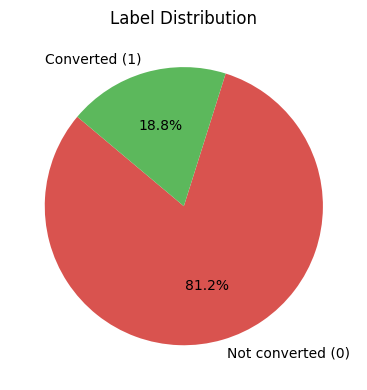

In [22]:
# ── 7.1 Training set overview ─────────────────────────────────────────────
print('=' * 60)
print('TRAINING SET OVERVIEW')
print('=' * 60)
print(f'Total quotes              : {len(df):,}')
print(f'Unique QuoteNumber values : {df["QuoteNumber"].nunique():,}')
print(f'Date range                : {df["Original_Quote_Date"].min().date()} → {df["Original_Quote_Date"].max().date()}')
print(f'Positive rate             : {df["QuoteConversion_Flag"].mean():.3%}')
print(f'Numeric features          : {X_num.shape[1]}')
print(f'Binary features           : {X_bin.shape[1]}')
print(f'Categorical features      : {X_cat.shape[1]}')
print()

label_counts = pd.Series(Y).value_counts().sort_index()
label_pct    = pd.Series(Y).value_counts(normalize=True).sort_index() * 100
print('LABEL DISTRIBUTION')
print('-' * 35)
for lbl, cnt, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    name = 'Converted (1)' if lbl == 1 else 'Not converted (0)'
    print(f'  {name:20s}: {cnt:8,}  ({pct:.2f} %)')
print()
print(f'Class imbalance ratio  : {label_counts[0]/label_counts[1]:.1f}:1  (negative : positive)')
print()
print('→ The dataset is imbalanced (≈81 % non-converted vs ≈19 % converted).')
print('  Use AUC / PR-AUC / class weights when modelling.')

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.pie(
    label_counts.values,
    labels=['Not converted (0)', 'Converted (1)'],
    autopct='%1.1f%%',
    colors=['#d9534f', '#5cb85c'],
    startangle=140,
)
ax.set_title('Label Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distribution.png', dpi=140)
plt.show()

Feature count by family:
GeographicField    244
PersonalField       89
PropertyField       68
CoverageField       20
SalesField          19
Field                7
day_of_week          1
day_of_month         1
day_of_year          1
month                1


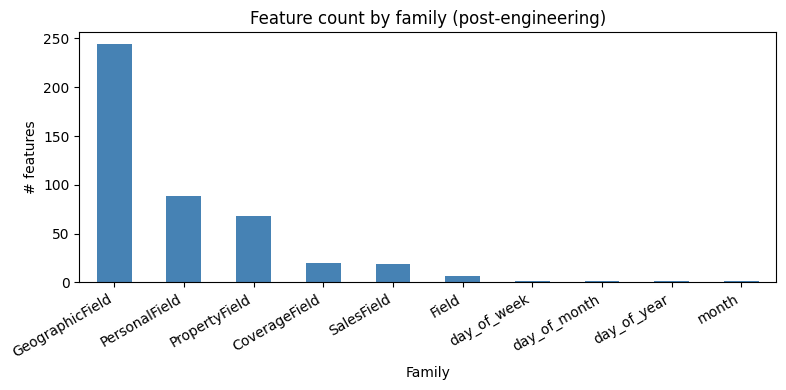


Top 10 raw columns by NaN rate (in cleaned cache):
PropertyField29    0.7696
PersonalField84    0.4763
PropertyField38    0.0047
PersonalField7     0.0004
PropertyField36    0.0004
PropertyField3     0.0003
PropertyField34    0.0003
PropertyField32    0.0003
PropertyField4     0.0002


In [23]:
# ── 7.2 Field-family overview ─────────────────────────────────────────────
# Group raw column names by their family prefix to summarise where the
# information lives. The Homesite analogue of Shoppers' offers-catalogue plot.
import re
FAMILY_REGEX = re.compile(r'^([A-Za-z]+?)Field')

def family(col):
    m = FAMILY_REGEX.match(col)
    if m:
        return m.group(1) + 'Field'
    if col.startswith('Field'):
        return 'Field'
    return col.split('__')[0]

all_features = num_feature_names + bin_feature_names + cat_feature_names
fam_counts = pd.Series([family(c) for c in all_features]).value_counts().sort_values(ascending=False)
print('Feature count by family:')
print(fam_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
fam_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Feature count by family (post-engineering)')
ax.set_xlabel('Family')
ax.set_ylabel('# features')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_count_by_family.png', dpi=140)
plt.show()

# Top-10 raw columns by missingness (computed BEFORE the fillna step).
raw_for_missing = pd.read_parquet(cache_path)
missing_rates = raw_for_missing.isna().mean()
top_missing = missing_rates[missing_rates > 0].sort_values(ascending=False).head(10)
print('\nTop 10 raw columns by NaN rate (in cleaned cache):')
print(top_missing.round(4).to_string())

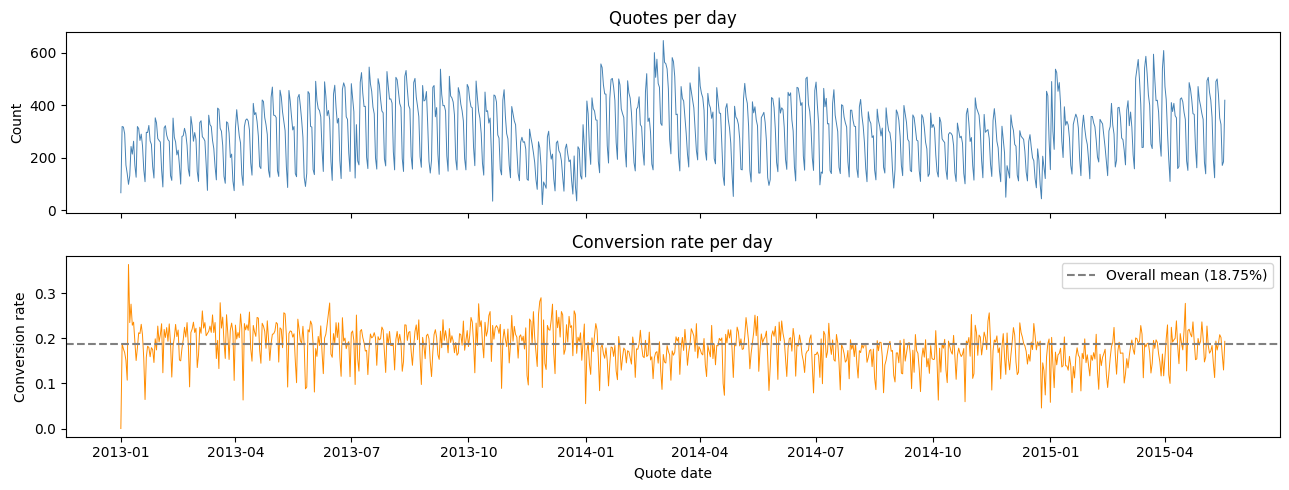

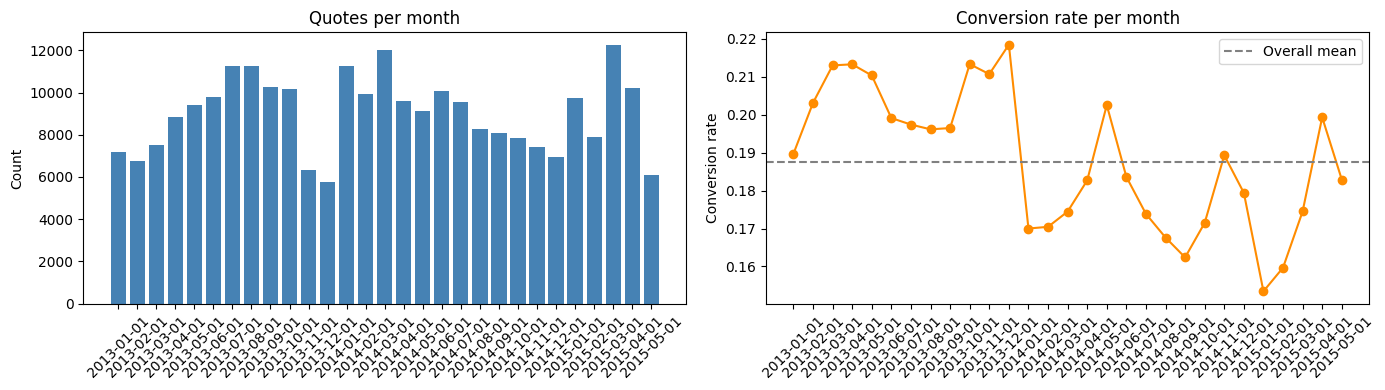

In [24]:
# ── 7.3 Temporal analysis ──────────────────────────────────────────────────
# The rolling-window experiment in notebook 01 partitions on this temporal axis;
# severe spikes or gaps would change how time steps should be defined.
daily = (
    pd.DataFrame({'quote_date': meta['quote_date'], 'y': Y})
    .groupby('quote_date')
    .agg(n_quotes=('y', 'size'), conversion_rate=('y', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(daily['quote_date'], daily['n_quotes'], color='steelblue', linewidth=0.7)
axes[0].set_title('Quotes per day')
axes[0].set_ylabel('Count')
axes[1].plot(daily['quote_date'], daily['conversion_rate'], color='darkorange', linewidth=0.7)
axes[1].axhline(Y.mean(), color='grey', linestyle='--', label=f'Overall mean ({Y.mean():.2%})')
axes[1].set_title('Conversion rate per day')
axes[1].set_ylabel('Conversion rate')
axes[1].set_xlabel('Quote date')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'daily_quotes_and_conversion_rate.png', dpi=140)
plt.show()

monthly = (
    pd.DataFrame({'month': pd.to_datetime(meta['quote_date']).dt.to_period('M').dt.to_timestamp(),
                  'y': Y})
    .groupby('month')
    .agg(n_quotes=('y', 'size'), conversion_rate=('y', 'mean'))
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly['month'].astype(str), monthly['n_quotes'], color='steelblue')
axes[0].set_title('Quotes per month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(monthly['month'].astype(str), monthly['conversion_rate'], marker='o', color='darkorange')
axes[1].axhline(Y.mean(), color='grey', linestyle='--', label='Overall mean')
axes[1].set_title('Conversion rate per month')
axes[1].set_ylabel('Conversion rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'monthly_quotes_and_conversion_rate.png', dpi=140)
plt.show()

Top 10 features by normalised mean difference (positive vs negative):
PropertyField38__missing    1.0
SalesField2A__missing       1.0
SalesField2B__missing       1.0
CoverageField1B__missing    1.0
CoverageField1A__missing    1.0
PersonalField7__missing     1.0
PropertyField36__missing    1.0
PropertyField3__missing     1.0
PropertyField32__missing    1.0
PropertyField34__missing    1.0


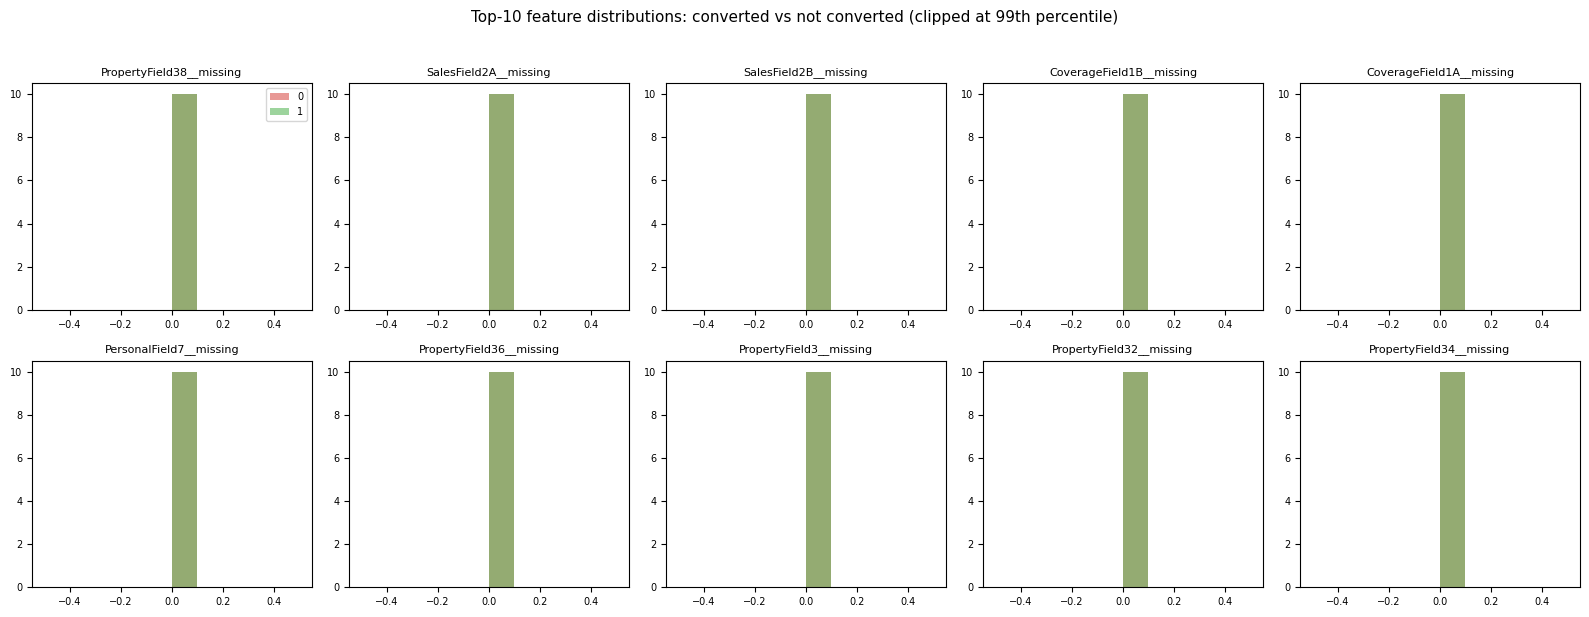

In [25]:
# ── 7.4 Feature distributions: top-10 by class separation ─────────────────────
# Cheap proxy for predictive power: normalised mean difference between classes.
X_eda = X.copy()
X_eda['__y__'] = Y
means = X_eda.groupby('__y__').mean(numeric_only=True)
diff = ((means.loc[1] - means.loc[0]) / (means.loc[1].abs() + means.loc[0].abs() + 1e-9)).abs()
top10 = diff.sort_values(ascending=False).head(10)

print('Top 10 features by normalised mean difference (positive vs negative):')
print(top10.round(4).to_string())

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for ax, feat in zip(axes, top10.index):
    vals0 = X_eda.loc[X_eda['__y__'] == 0, feat]
    vals1 = X_eda.loc[X_eda['__y__'] == 1, feat]
    q99 = X_eda[feat].quantile(0.99)
    bins = np.linspace(vals0.min(), q99, 30) if q99 > vals0.min() else 10
    ax.hist(vals0.clip(upper=q99), bins=bins, alpha=0.6, label='0', color='#d9534f', density=True)
    ax.hist(vals1.clip(upper=q99), bins=bins, alpha=0.6, label='1', color='#5cb85c', density=True)
    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7)
plt.suptitle('Top-10 feature distributions: converted vs not converted (clipped at 99th percentile)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'top10_feature_distributions.png', dpi=140)
plt.show()

Plotting conversion rate by category for: ['Field6', 'Field10', 'CoverageField8', 'CoverageField9']


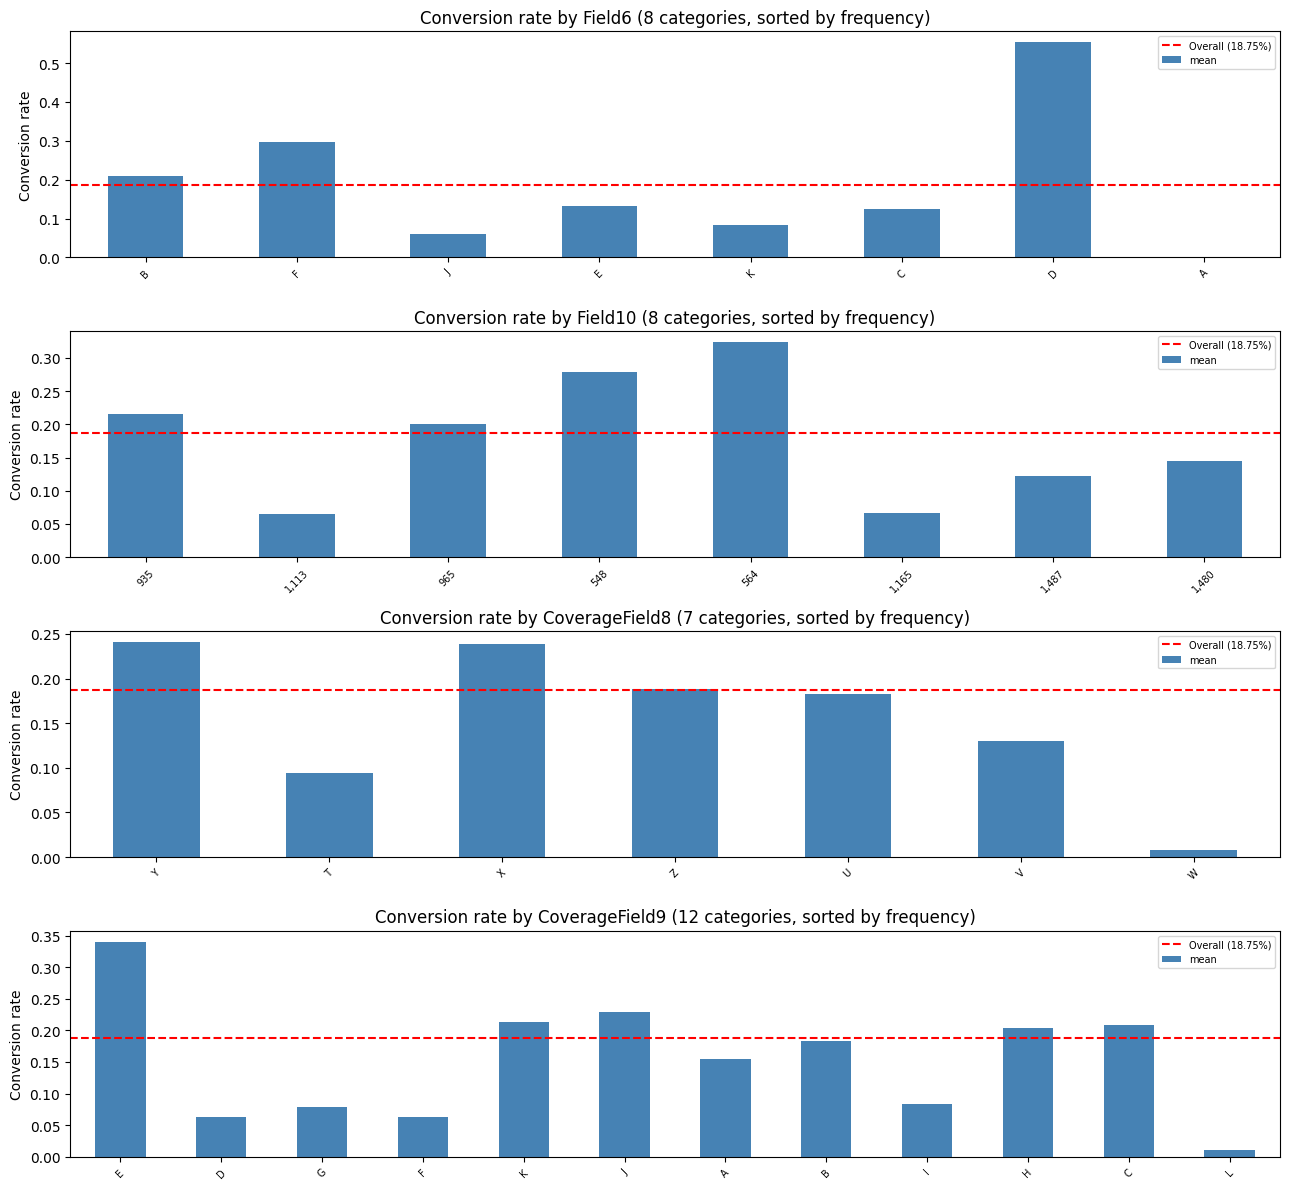

In [26]:
# ── 7.5 Conversion rate conditioned on a few categorical features ────────────────
# Pick up to 4 categorical columns with a manageable cardinality and visualise
# how conversion rate varies across their categories.
MAX_CAT_CARDINALITY = 60
cat_for_plot = [c for c in cat_feature_names if X_cat[c].nunique() <= MAX_CAT_CARDINALITY][:4]

if not cat_for_plot:
    print('No categorical column with manageable cardinality found for the rate plot.')
else:
    print(f'Plotting conversion rate by category for: {cat_for_plot}')
    fig, axes = plt.subplots(len(cat_for_plot), 1, figsize=(13, 3 * len(cat_for_plot)))
    if len(cat_for_plot) == 1:
        axes = [axes]
    for ax, c in zip(axes, cat_for_plot):
        rate = pd.DataFrame({'cat': X_cat[c].values, 'y': Y}).groupby('cat')['y'].agg(['size', 'mean'])
        rate = rate.sort_values('size', ascending=False)
        rate['mean'].plot(kind='bar', ax=ax, color='steelblue')
        ax.axhline(Y.mean(), color='red', linestyle='--', label=f'Overall ({Y.mean():.2%})')
        ax.set_title(f'Conversion rate by {c} ({len(rate)} categories, sorted by frequency)')
        ax.set_ylabel('Conversion rate')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'conversion_rate_by_categorical.png', dpi=140)
    plt.show()